# Phase 2: Data Understanding, Exploratory Data Analysis
We explore both datasets to understand structure, quality, and key patterns before modeling.

## 1. Global Imports and Settings

In [6]:
# Standard library
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import chi2_contingency, skew
import statsmodels.api as sm

warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 120})

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


def cramers_v(confusion_matrix: np.ndarray) -> float:
    """Compute Cramer's V effect size from a chi-square contingency table."""
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))


print("Setup complete.")

Setup complete.


## 2. Load Datasets

In [7]:
# Load raw datasets
items = pd.read_csv(DATA_RAW / 'items.csv', sep='|')
train = pd.read_csv(DATA_RAW / 'train.csv', sep='|')

print(f"Items Shape: {items.shape}")
print(f"Train Shape: {train.shape}")

# Quick sanity check: both files must have more than one column (wrong sep = 1 col)
assert items.shape[1] > 1, "items.csv failed to parse, check delimiter"
assert train.shape[1] > 1, "train.csv failed to parse, check delimiter"

Items Shape: (22035, 11)
Train Shape: (2756003, 11)


## 3. Dataset Overview
> `items.csv` Static product attributes that do not change over time. Joined to train.csv via `pid`.
>
> `train.csv` Time-varying interaction data recording user behavior across 92 days. The target is one of three mutually exclusive actions per row: `click`, `basket`, or `order`.

### 3.1 items.csv: Initial Exploration

In [8]:
# First 10 rows to get a sense of the data
items.head(10)

,pid,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
1,2,1,2FOI,80,ST,Tab,0,40,NaN,NaN,10.89
2,3,1,2FOI,10,G,GLO,0,40,NaN,NaN,16.45
3,4,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
4,5,2,10OJ03JS,8,ST,PUL,0,40,1.00,NaN,22.53
5,6,1,2FOI,10,G,GLO,0,40,2.00,NaN,9.85
6,7,3,21OKG,15,ST,TRA,0,53,3.00,NaN,21.45
7,8,1,2FOI,80,ST,TAB,0,40,2.00,NaN,10.89
8,9,1,2FOI,10,G,GLO,0,40,NaN,NaN,9.85
9,10,4,12OS2F,30,ST,FTA,0,40,4.00,A,21.99


In [9]:
# Structure, Data Types, and Missing Values
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22035 entries, 0 to 22034
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             22035 non-null  int64  
 1   manufacturer    22035 non-null  int64  
 2   group           22035 non-null  str    
 3   content         22035 non-null  str    
 4   unit            22035 non-null  str    
 5   pharmForm       19708 non-null  str    
 6   genericProduct  22035 non-null  int64  
 7   salesIndex      22035 non-null  int64  
 8   category        17408 non-null  float64
 9   campaignIndex   1338 non-null   str    
 10  rrp             22035 non-null  float64
dtypes: float64(2), int64(4), str(5)
memory usage: 1.8 MB


> #### Observations and Investigation Plan
> From the structure and data types above, the following require further investigation:
>
> 1. **Missing values:** `campaignIndex`, `category`, and `pharmForm` show non-null counts below 22,035. (quantify the gaps)
> 2. **Low-cardinality integers:** `salesIndex` and `genericProduct` are stored as `int64` but may represent codes or flags rather than true numeric values. (check distinct values)
> 3. **Mixed-format column:** `content` is stored as `str` and likely contains mixed formats (e.g., plain floats alongside patterns like `"5X10"`). (inspect sample values)
> 4. **Forced numeric type:** `category` shows as `float64`, which typically indicates NaNs forced a numeric cast on a logically categorical column. (confirm after missing value analysis)

In [10]:
# 1. Summary of missing values across all columns
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate count and percentage of missing values for each column."""
    total = df.isnull().sum()
    percent = (total / len(df) * 100).round(2)
    summary = pd.DataFrame({'Total Missing': total, 'Percent Missing': percent})
    return summary[summary['Total Missing'] > 0].sort_values('Total Missing', ascending=False)
missing_summary(items)

,Total Missing,Percent Missing
campaignIndex,20697,93.93
category,4627,21.00
pharmForm,2327,10.56


In [11]:
# 2. Distinct value counts for low-cardinality integer columns
for col in ['salesIndex', 'genericProduct']:
    unique_vals = [int(val) for val in sorted(items[col].unique())]
    print(f"{col:<20}{items[col].nunique():>2} unique values   {unique_vals}")

salesIndex           4 unique values   [40, 44, 52, 53]
genericProduct       2 unique values   [0, 1]


In [12]:
# 3. Inspect content column for mixed formats
print(items['content'].drop_duplicates().head(20).tolist())

['80', '10', '8', '15', '30', '60', '14', '7', '75', '100', '20', '1', '250', '5X10', '125', '90', '160', '400', '3', '50']


In [13]:
# 4. Confirm if category is categorical despite float64 dtype
unique_cats = sorted([int(v) for v in items['category'].dropna().unique()])
print(f"category: {items['category'].nunique():>3} unique values\n{unique_cats}")

category: 409 unique values
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,

> #### items.csv: Findings Summary
>
> **Shape:** 22,035 products x 11 attributes (`pid`, `manufacturer`, `group`, `content`, `unit`, `pharmForm`, `genericProduct`, `salesIndex`, `category`, `campaignIndex`, `rrp`)
>
> **Missing values:**
> - `campaignIndex`: 20,697 missing (93.9%), the majority of products carry no campaign label
> - `category`: 4,627 missing (21.0%), a significant gap that requires further investigation
> - `pharmForm`: 2,327 missing (10.6%), moderate missingness that may carry predictive signal
>
> **Dtype observations:**
> - `salesIndex`: stored as `int64` with only 4 distinct codes [40, 44, 52, 53], represents a dispensing regulation category, not a numeric measurement
> - `genericProduct`: stored as `int64` but is a binary flag [0, 1], confirms it is categorical
> - `category`: stored as `float64` due to NaNs forcing a numeric cast, but has 409 sequential integer codes (range 1 to 409), logically categorical
> - `content`: stored as `str` and requires format inspection (pending Investigation 3)
>
> **No issues:**
> - `pid`, `manufacturer`, `rrp`, `unit`, and `group` all loaded correctly with no missing values

### 3.2 train.csv: Initial Exploration

In [14]:
# First 10 rows to get a sense of the data
train.head(10)

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue
0,1,1,6570,0,2,14.60,1,0,0,16.89,0.00
1,2,1,14922,1,1,8.57,0,1,0,8.75,0.00
2,3,1,16382,0,1,14.77,0,1,0,16.06,0.00
3,4,1,1145,1,1,6.59,0,0,1,6.55,6.55
4,5,1,3394,0,1,4.39,0,0,1,4.14,4.14
5,6,1,3661,0,1,13.66,0,0,1,10.03,10.03
6,7,1,3856,1,1,3.03,0,0,1,3.58,3.58
7,8,1,16963,0,1,8.78,1,0,0,8.75,0.00
8,9,1,14560,0,1,10.84,1,0,0,12.04,0.00
9,10,1,4853,1,1,9.12,1,0,0,8.75,0.00


In [15]:
# Structure, Data Types, and Missing Values
train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2756003 entries, 0 to 2756002
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   lineID           2756003 non-null  int64  
 1   day              2756003 non-null  int64  
 2   pid              2756003 non-null  int64  
 3   adFlag           2756003 non-null  int64  
 4   availability     2756003 non-null  int64  
 5   competitorPrice  2655316 non-null  float64
 6   click            2756003 non-null  int64  
 7   basket           2756003 non-null  int64  
 8   order            2756003 non-null  int64  
 9   price            2756003 non-null  float64
 10  revenue          2756003 non-null  float64
dtypes: float64(3), int64(8)
memory usage: 231.3 MB


> #### Observations and Investigation Plan
>
> From the structure and data types above, the following require further investigation:
>
> 1. **Missing values:** `competitorPrice` is the only column with  missing values. (quantify and assess whether missingness carries signal)
> 2. **Low-cardinality integers:** `adFlag`, `availability`, `click`, `basket`, and `order` are stored as `int64` but likely represent flags or codes(Check distinct values)
> 3. **Revenue behavior:** `revenue` is `float64` and expected to be nonzero only for orders (confirm this relationship holds across the full dataset)
> 4. **Target variable:** `click`, `basket`, and `order` should be mutually exclusive with exactly one flag set to 1 per row (verify this constraint holds across all 2,756,003 rows)

In [16]:
# 1. Quantify missing values
missing_summary(train)

,Total Missing,Percent Missing
competitorPrice,100687,3.65


In [17]:
# 2. Distinct values for low-cardinality integer columns
for col in ['adFlag', 'availability', 'click', 'basket', 'order']:
    unique_vals = [int(v) for v in sorted(train[col].unique())]
    print(f"{col:<20}{train[col].nunique():>2} unique values   {unique_vals}")

adFlag               2 unique values   [0, 1]
availability         4 unique values   [1, 2, 3, 4]
click                2 unique values   [0, 1]
basket               2 unique values   [0, 1]
order                2 unique values   [0, 1]


In [18]:
# 3. Confirm revenue is nonzero only for orders
revenue_check = train.groupby('order')['revenue'].agg(['min', 'max', 'mean', 'median'])
print(revenue_check)

       min    max  mean  median
order                          
0     0.00   0.00  0.00    0.00
1     0.07 887.70 14.66    9.86


In [19]:
# 4. Verify mutual exclusivity of click, basket, order
action_sum = train[['click', 'basket', 'order']].sum(axis=1)
print(f"Rows where exactly one action = 1 : {(action_sum == 1).sum():>10,}")
print(f"Rows where no action is set       : {(action_sum == 0).sum():>10,}")
print(f"Rows where more than one action   : {(action_sum > 1).sum():>10,}")

Rows where exactly one action = 1 :  2,756,003
Rows where no action is set       :          0
Rows where more than one action   :          0


> #### train.csv: Findings Summary
>
> **Missing values:**
> - `competitorPrice`: 100,687 missing (3.65%), the only column with gaps; missingness may carry predictive signal and will be tested as a binary flag
>
> **Dtype observations:**
> - `adFlag`: stored as `int64` but is a binary flag [0, 1], confirms it is categorical
> - `availability`: stored as `int64` with only 4 distinct codes [1, 2, 3, 4], represents a status category, not a numeric measurement
> - `click`, `basket`, `order`: all stored as `int64` binary flags [0, 1], mutually exclusive across all 2,756,003 rows with no exceptions
>
> **Target variable confirmed:**
> - Every row has exactly one action set to 1; the mutual exclusivity constraint holds perfectly across the full dataset
>
> **Revenue behavior confirmed:**
> - `revenue` is strictly 0.0 for all non-orders and ranges from 0.07 to 887.70 for orders (mean 14.66, median 9.86)
>
> **No issues:**
> - `lineID`, `day`, `pid`, `price` all loaded correctly with no missing values

## 4. Target Variable Analysis

The target variable is the user action recorded per interaction: `click`, `basket`, or `order`.
Every row has exactly one action set to 1, making this a 3-class classification problem.
Before analyzing any features, we must understand what we are predicting and how balanced the classes are.

**This section answers four questions:**

1. **Class distribution:** How are clicks, baskets, and orders distributed across all interactions?
2. **Imbalance assessment:** Is the imbalance severe enough to require special handling or stratified sampling?

## 4.1 Class Distribution across all interactions

In [20]:
# Calculate total counts and percentages for each action type
action_counts = train[['click', 'basket', 'order']].sum().rename('Count')
action_precent = (action_counts / len(train) * 100).round(2).rename('Percent')

# Combine into a single DataFrame for display
action_summary = pd.concat([action_counts, action_precent], axis=1)
print(action_summary)

          Count  Percent
click   1582827    57.43
basket   468086    16.98
order    705090    25.58


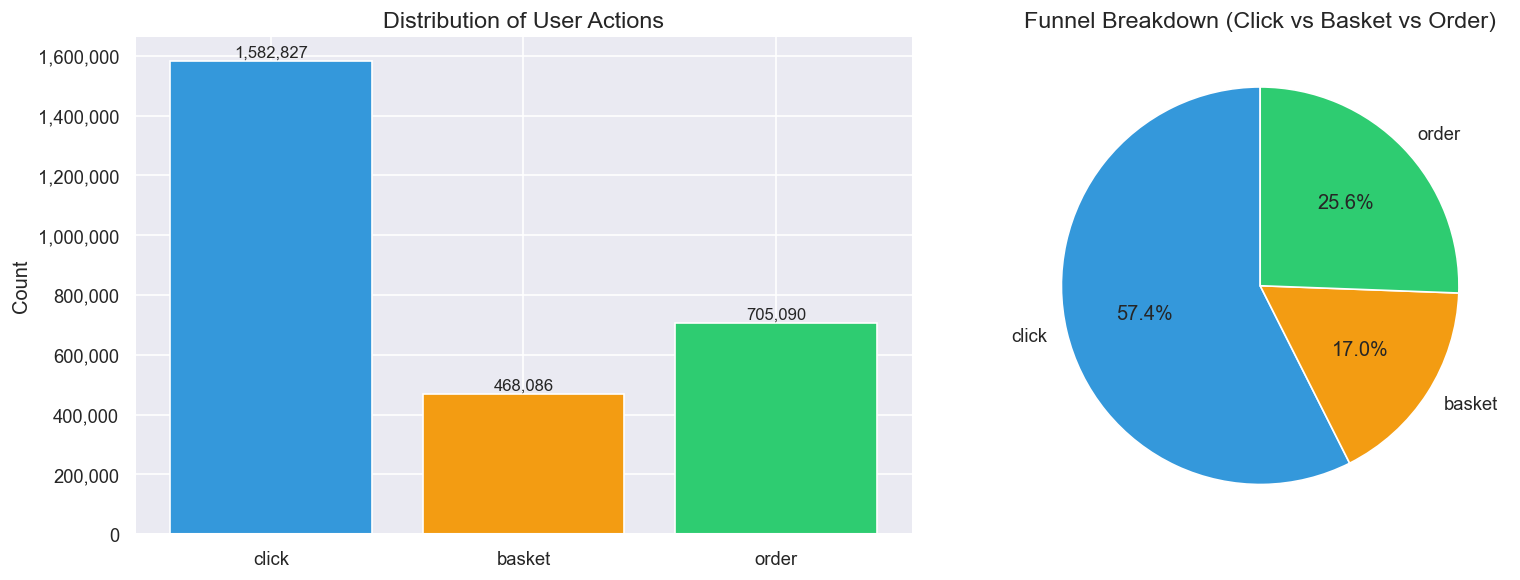

In [21]:
# Visualize class distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'click': '#3498db', 'basket': '#f39c12', 'order': '#2ecc71'}
action_order = ['click', 'basket', 'order']
action_vals = [int(action_counts[a]) for a in action_order]
bar_colors = [colors[a] for a in action_order]

# Bar chart
axes[0].bar(action_order, action_vals, color=bar_colors, edgecolor='white')
axes[0].set_title('Distribution of User Actions', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (action, val) in enumerate(zip(action_order, action_vals)):
    axes[0].text(i, val + len(train) * 0.005, f'{val:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(action_vals, labels=action_order, colors=bar_colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Funnel Breakdown (Click vs Basket vs Order)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '01_target_distribution.png', bbox_inches='tight')
plt.show()

### 4.2 Purchase Funnel Analysis

> The conversion funnel from click to basket to order reveals where users drop off in the buying journey. Quantifying drop-off rates at each stage directly informs which transitions the model should focus on and where pricing interventions are most likely to influence revenue.

In [22]:
# Purchase funnel analysis
total_actions = len(train)
number_of_clicks = train['click'].sum()
number_of_baskets = train['basket'].sum()
number_of_orders = train['order'].sum()
reached_intent_to_order    = number_of_baskets + number_of_orders

print(f"Browsed only (no intent)        : {number_of_clicks / total_actions * 100:.2f}%")
print(f"Showed intent to purchase       : {reached_intent_to_order / total_actions * 100:.2f}%")
print(f"Completed purchase rate         : {number_of_orders / total_actions * 100:.2f}%")
print(f"Intent to order conversion rate : {number_of_orders / reached_intent_to_order * 100:.2f}%")

Browsed only (no intent)        : 57.43%
Showed intent to purchase       : 42.57%
Completed purchase rate         : 25.58%
Intent to order conversion rate : 60.10%


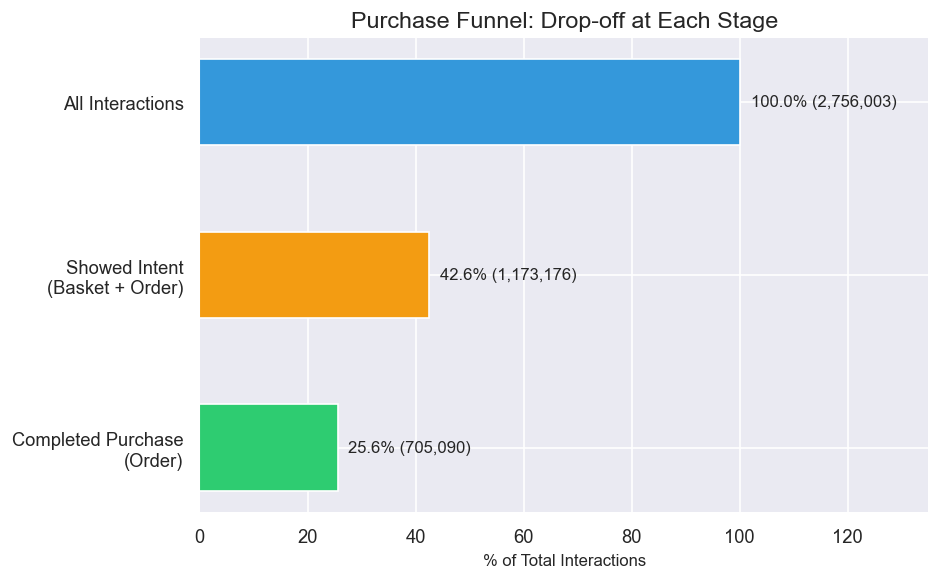

In [23]:
# Visualize the purchase funnel with a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# Define funnel stages, values, percentages, and colors
funnel_labels = ['All Interactions', 'Showed Intent\n(Basket + Order)', 'Completed Purchase\n(Order)']
funnel_vals   = [total_actions, int(reached_intent_to_order), int(number_of_orders)]
funnel_pcts   = [v / total_actions * 100 for v in funnel_vals]
funnel_colors = ['#3498db', '#f39c12', '#2ecc71']

# Create horizontal bars with reversed order for top-down funnel visualization
bars = ax.barh(funnel_labels[::-1], funnel_pcts[::-1], color=funnel_colors[::-1], edgecolor='white', height=0.5)

# Annotate bars with percentage and count labels
for bar, pct, val in zip(bars, funnel_pcts[::-1], funnel_vals[::-1]):
    ax.text(bar.get_width() + 2 , bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}% ({val:,})', va='center', fontsize=10)

ax.set_title('Purchase Funnel: Drop-off at Each Stage', fontsize=14)
ax.set_xlabel('% of Total Interactions', fontsize=10)
ax.set_xlim(0, 135)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '02_purchase_funnel.png', bbox_inches='tight')
plt.show()

> **Purchase funnel insight:** Across 2,756,003 interactions, 57.43% of users browsed without showing any purchase intent, while 42.57% progressed to basket or order. Of those who showed intent, 60.10% completed a purchase, which is already a strong conversion rate. This means the primary business lever is not improving the intent-to-order conversion, but rather moving more users from browsing into the intent stage. Pricing, advertising, and availability are therefore most impactful at the top of the funnel, and the model should prioritize features that distinguish browsers from intenders.
>
> **Imbalance assessment:** The class distribution shows moderate imbalance: click (57.43%), order (25.58%), and basket (16.98%). No class is vanishingly small, and the minority class (basket) still represents over 468,000 interactions. This level of imbalance does not require aggressive resampling. Stratified train/test splitting is sufficient to preserve class proportions, and class-weighted loss functions can be applied during modeling if needed. This decision will be revisited in Phase 3 once the modeling approach is confirmed.

## 5. Univariate Analysis

Before exploring relationships between features and the target, we examine each feature individually.
This reveals distributions, skewness, outliers, and value ranges that inform both feature engineering and modeling decisions.

**This section covers:**

1. **Numeric features:** `price`, `competitorPrice`, `rrp` (distributions, skewness, outliers)
2. **Binary flags:** `adFlag`, `genericProduct` (value counts, order rates)
3. **Categorical features:** `availability`, `salesIndex`, `campaignIndex` (value counts, order rates)
4. **Quantity estimation:** `revenue / price` (distribution, outliers, single-unit dominance)
5. **High cardinality features:** `manufacturer`, `group`, `category` (top values, coverage)
6. **Temporal feature:** `day` (interaction volume over time, behavioral shifts)
7. **Special case:** `content` (mixed format inspection)

### 5.1 Numeric features: descriptive statistics

In [24]:
# 5.1 Descriptive statistics for numeric features
numeric_cols = ['price', 'competitorPrice', 'rrp']

stats = train[['pid', 'price', 'competitorPrice']].merge(
    items[['pid', 'rrp']], on='pid', how='left'
)

print(stats[numeric_cols].describe().T.round(2))

                     count  mean   std  min  25%   50%   75%    max
price           2756003.00 13.85 13.62 0.02 6.00  9.85 16.45 378.84
competitorPrice 2655316.00 12.77 12.75 0.00 5.48  8.99 15.06 264.59
rrp             2756003.00 18.31 18.66 0.07 7.98 13.17 21.95 404.97


> A price of zero for a competitor price is not a real price, it is either a data entry error or a missing value that was coded as zero. If we leave it as zero and later calculate `price`/ `competitorPrice` we get division by zero, producing infinity values that will break any model.

In [25]:
# 5.1 Check how many rows have competitorPrice = 0
zero_competitor_price_count = (train['competitorPrice'] == 0).sum()
print(f"Number of rows with competitorPrice = 0: {zero_competitor_price_count:,}")

Number of rows with competitorPrice = 0: 976


In [26]:
# 5.1 Outlier investigation for price columns
for col in numeric_cols:
    data = stats[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    upper  = q3 + 1.5 * iqr
    lower  = q1 - 1.5 * iqr
    n_outliers = ((data < lower) | (data > upper)).sum()
    print(f"{col:<20} IQR: {iqr:.2f}   Lower: {lower:.2f}   Upper: {upper:.2f}   Outliers: {n_outliers:,} ({n_outliers / len(data) * 100:.2f}%)")

price                IQR: 10.45   Lower: -9.67   Upper: 32.12   Outliers: 204,491 (7.42%)
competitorPrice      IQR: 9.58   Lower: -8.89   Upper: 29.43   Outliers: 194,482 (7.32%)
rrp                  IQR: 13.97   Lower: -12.97   Upper: 42.91   Outliers: 191,821 (6.96%)


> **Outlier Observations:**
> - Lower bound is negative for all three columns, which is impossible for a price. This means no lower outliers exist; all outliers are on the high end.
> - A 7% outlier rate is significant but not alarming for pharmaceutical pricing. High-priced specialty medications naturally create long tails.
> - The key question is whether these are real values or data errors, which the next cell investigates.

In [27]:
# 5.1 Investigate the top 10 highest prices in each column to assess if they are plausible or data errors
print("Top 10 highest prices:")
print(stats.nlargest(10, 'price')[['pid', 'price', 'competitorPrice', 'rrp']].to_string(index=False))

Top 10 highest prices:
  pid  price  competitorPrice    rrp
20002 378.84              NaN 328.33
12746 374.59              NaN 404.97
12746 374.59              NaN 404.97
12746 374.59              NaN 404.97
12746 374.59              NaN 404.97
12746 372.72              NaN 404.97
20002 340.64              NaN 328.33
13673 334.01              NaN 333.53
13469 323.98           192.50 280.79
13768 323.98           207.90 280.79


> **Price outliers insight:** The IQR method flags approximately 7% of rows as outliers across all three price columns, all on the high end. Investigation of the top 10 highest-priced products confirms these are legitimate high-value pharmaceutical products where `price` and `rrp` are consistently aligned. No erroneous values were identified. The outliers will be retained, and ratio features (`price/rrp`, `price/competitorPrice`) will naturally normalize these extreme values in Phase 3.

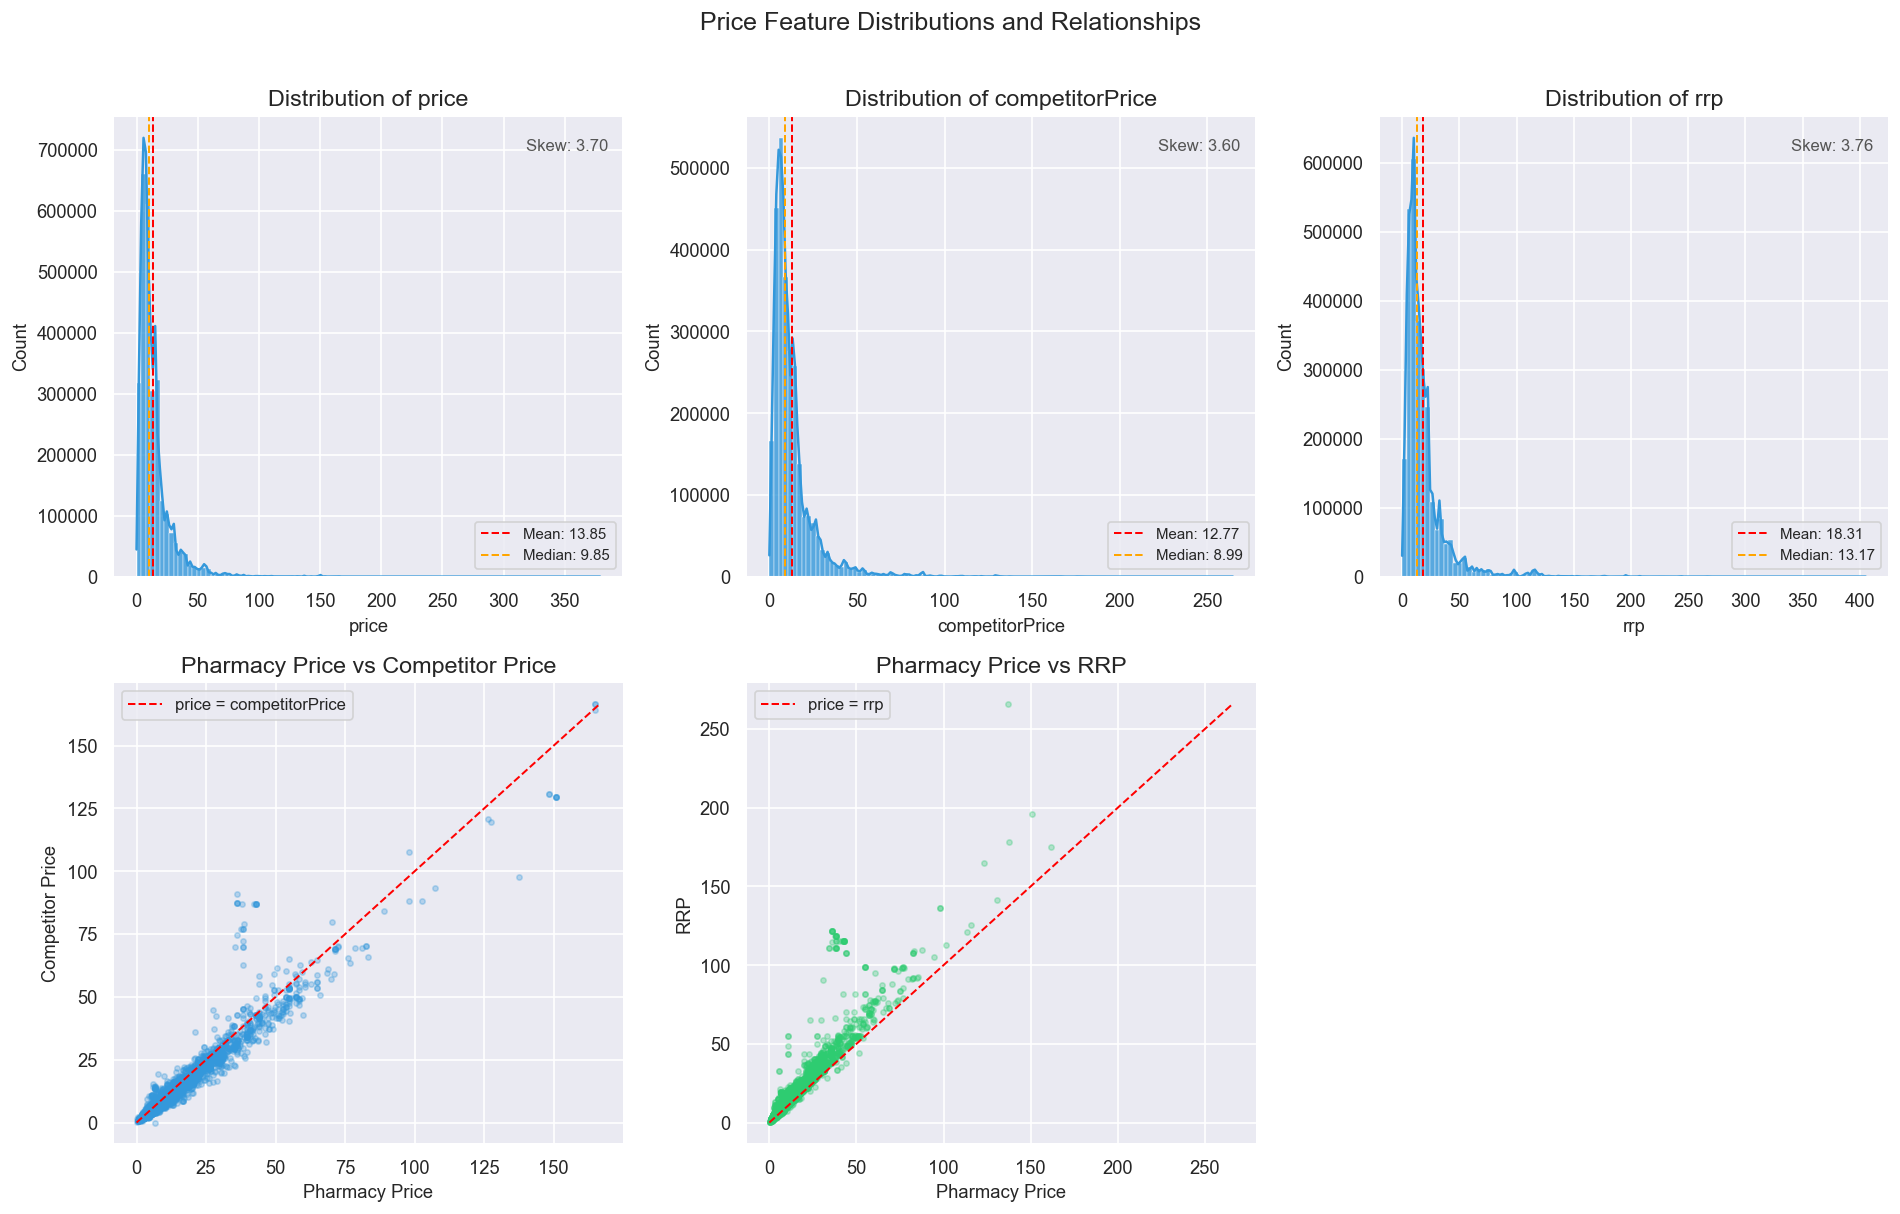

In [28]:
# 5.1 Numeric features: distribution plots with skewness annotation
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: distribution plots for each price column
for ax, col in zip(axes[0], numeric_cols):
    data     = stats[col].dropna()
    skewness = skew(data)
    sns.histplot(data, bins=100, kde=True, ax=ax, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)
    ax.text(0.97, 0.95, f'Skew: {skewness:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='#555555')

# Row 2, left: price vs competitorPrice scatter
sample = stats[['price', 'competitorPrice']].dropna().sample(5000, random_state=RANDOM_STATE)
axes[1][0].scatter(sample['price'], sample['competitorPrice'], alpha=0.3, s=10, color='#3498db')
max_val = max(sample['price'].max(), sample['competitorPrice'].max())
axes[1][0].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.2, label='price = competitorPrice')
axes[1][0].set_title('Pharmacy Price vs Competitor Price', fontsize=14)
axes[1][0].set_xlabel('Pharmacy Price', fontsize=11)
axes[1][0].set_ylabel('Competitor Price', fontsize=11)
axes[1][0].legend(fontsize=10)
axes[1][0].spines[['top', 'right']].set_visible(False)

# Row 2, middle: price vs rrp scatter
sample_rrp = stats[['price', 'rrp']].dropna().sample(5000, random_state=RANDOM_STATE)
axes[1][1].scatter(sample_rrp['price'], sample_rrp['rrp'], alpha=0.3, s=10, color='#2ecc71')
max_val_rrp = max(sample_rrp['price'].max(), sample_rrp['rrp'].max())
axes[1][1].plot([0, max_val_rrp], [0, max_val_rrp], color='red', linestyle='--', linewidth=1.2, label='price = rrp')
axes[1][1].set_title('Pharmacy Price vs RRP', fontsize=14)
axes[1][1].set_xlabel('Pharmacy Price', fontsize=11)
axes[1][1].set_ylabel('RRP', fontsize=11)
axes[1][1].legend(fontsize=10)
axes[1][1].spines[['top', 'right']].set_visible(False)

# Row 2, right: hide unused subplot
axes[1][2].set_visible(False)

plt.suptitle('Price Feature Distributions and Relationships', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '03_price_distributions.png', bbox_inches='tight')
plt.show()

> **Price features insight:** All three price columns (`price`, `competitorPrice`, `rrp`) show strong right skew (3.7, 3.6, and 3.8 respectively), with the vast majority of products priced below 50 and long tails extending to 379, 265, and 405. The mean is consistently higher than the median across all three columns, confirming the skew is driven by a small number of high-priced products. The scatter plots confirm strong collinearity between all three columns. The price vs competitor price plot shows points clustered close to the diagonal but with a slight bias above it, visually suggesting competitors are often more expensive than the pharmacy, though this may reflect sampling variation rather than the full dataset distribution. The full dataset statistics confirm competitor prices (mean 12.8) are marginally lower than pharmacy prices (mean 13.9) on average. Notable outliers exist where pharmacy prices around 25 to 40 face competitor prices of 70 to 90, large gaps worth investigating. The price vs RRP plot confirms that the pharmacy consistently prices below RRP, with wider spread indicating greater variability in discount depth across products. A small number of products are priced above RRP, possibly due to outdated RRP values, specialty items, or different pack sizes. The `competitorPrice` minimum of 0.00 confirms the presence of 976 zero rows that must be recoded to NaN in Phase 3. Given the strong collinearity, the three raw columns will be replaced by ratio features (`price/rrp`, `price/competitorPrice`) in Phase 3 to capture competitive positioning and discount depth as meaningful business signals.

In [29]:
# 5.1 Correlation matrix for price columns
price_corr_matrix = stats[numeric_cols].corr().round(2)
print("Correlation matrix for price columns:")
print(price_corr_matrix)

Correlation matrix for price columns:
                 price  competitorPrice  rrp
price             1.00             0.95 0.94
competitorPrice   0.95             1.00 0.97
rrp               0.94             0.97 1.00


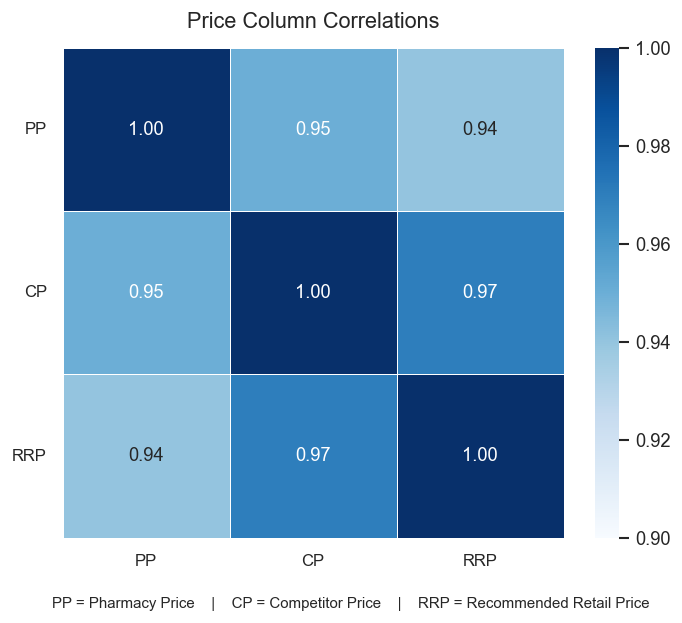

In [30]:
# 5.1 Visualize correlation matrix with a heatmap

abbr_labels = ['PP', 'CP', 'RRP']

corr_display = price_corr_matrix.copy()
corr_display.index = abbr_labels
corr_display.columns = abbr_labels

fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    corr_display,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    vmin=0.9,
    vmax=1.0,
    ax=ax,
    annot_kws={'size':11}
)

ax.set_title('Price Column Correlations', fontsize=13, pad=12)
ax.set_xticklabels(abbr_labels, fontsize=10, rotation=0)
ax.set_yticklabels(abbr_labels, fontsize=10, rotation=0)

# Abbreviation legend below chart
legend_text = (
    "PP = Pharmacy Price    |    "
    "CP = Competitor Price    |    "
    "RRP = Recommended Retail Price"
)

fig.text(
    0.5, -0.03,
    legend_text,
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '03c_price_correlation.png', bbox_inches='tight')
plt.show()

### 5.2 Binary flags

In [31]:
# 5.2 Binary flags: value counts and order rates
binary_cols = ['adFlag', 'genericProduct']

for col in binary_cols:
    source = train if col == 'adFlag' else items
    counts = source[col].value_counts().sort_index()
    count_percent = (counts / len(source) * 100).round(2)
    print(f"{col} value counts:")
    for val, count, pct in zip(counts.index, counts.values, count_percent.values):
        print(f"  {val} : {count:>10,} ({pct:.2f}%)")
    print()

adFlag value counts:
  0 :  1,880,176 (68.22%)
  1 :    875,827 (31.78%)

genericProduct value counts:
  0 :     21,293 (96.63%)
  1 :        742 (3.37%)



> **Binary flags value counts insight:** `adFlag` shows that 31.8% of interactions involve advertised products, meaning roughly one in three product interactions occurs under an active marketing campaign. `genericProduct` is heavily skewed toward branded products (96.6%), with only 742 out of 22,035 products being generic (3.4%). Despite their scarcity in the catalog, generics appear in a meaningful share of interactions, suggesting they attract disproportionate traffic relative to their catalog share.

In [47]:
# 5.2 Order rates by binary flags
print("Order rates by adFlag:")
print(train.groupby('adFlag')['order'].mean().mul(100).round(2).to_string())
print()

# Merge train with items to get genericProduct flag for order rate analysis
train_with_generic = train.merge(items[['pid', 'genericProduct']], on='pid', how='left')
print("Order rates by genericProduct:")
print(train_with_generic.groupby('genericProduct')['order'].mean().mul(100).round(2).to_string())
print()

#edit @Said: Interesting to know what the generic products with or without the add flag have for return
print("Order rates by genericProduct and adFlag:")

order_rates_combo = (
    train_with_generic
    .groupby(['genericProduct', 'adFlag'])['order']
    .mean()
    .mul(100)
    .round(2)
    .unstack()  # makes it easier to read
)

print(order_rates_combo.to_string())

Order rates by adFlag:
adFlag
0   22.48
1   32.24

Order rates by genericProduct:
genericProduct
0   24.17
1   37.58

Order rates by genericProduct and adFlag:
adFlag             0     1
genericProduct            
0              21.61 30.21
1              32.63 42.82


> **Binary flags order rates insight:** Both flags show clear and meaningful differences in order rates. Advertised products convert at 32.2% compared to 22.5% for non-advertised products, a 9.8 percentage point lift confirming that marketing campaigns meaningfully drive purchase decisions. Generic products convert at 37.6% compared to 24.2% for branded products, a 13.4 percentage point lift likely driven by their lower price points making purchase decisions easier. Despite generics representing only 3.4% of the product catalog, their consistently higher conversion rate makes `genericProduct` a strong candidate predictor. Both flags will be retained as features in the model.

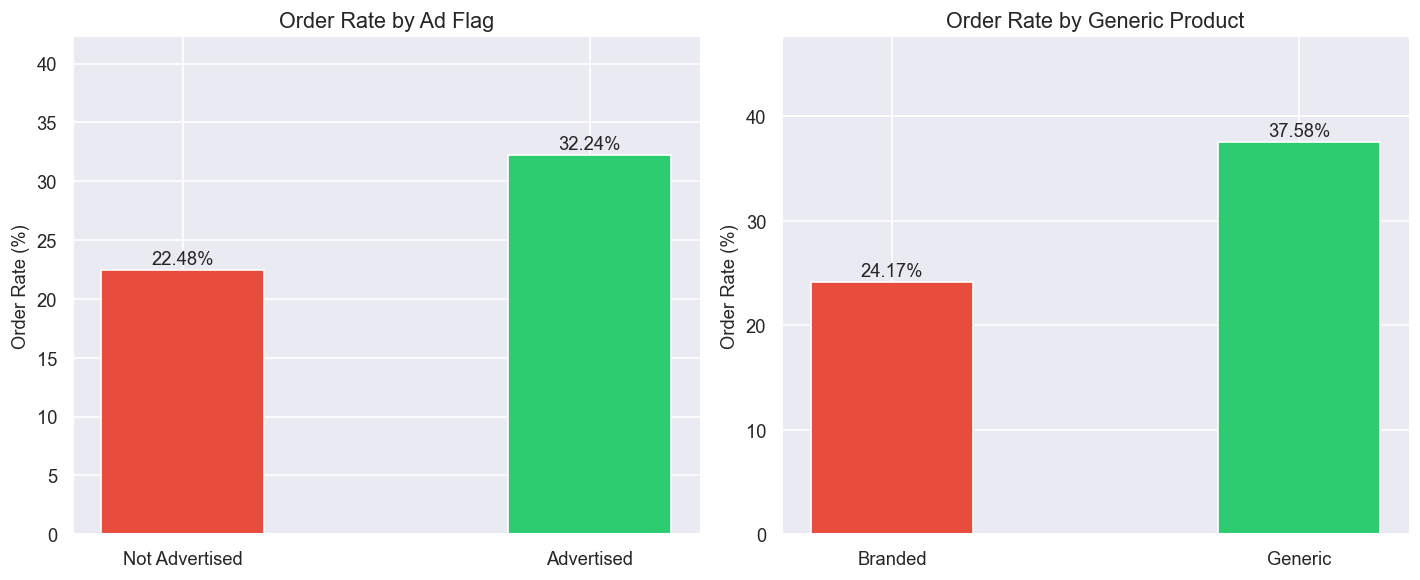

In [33]:
# 5.2 Order rates by binary flags visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

flag_configs = [
    ('adFlag', train, ['Not Advertised', 'Advertised'], 'Order Rate by Ad Flag'),
    ('genericProduct', train_with_generic, ['Branded', 'Generic'], 'Order Rate by Generic Product'),
]

for ax, (col, source, labels, title) in zip(axes, flag_configs):
    rates = source.groupby(col)['order'].mean().mul(100).round(2).values
    bars = ax.bar(labels, rates, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
    for bar, val in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Order Rate (%)', fontsize=11)
    ax.set_ylim(0, rates.max() + 10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '04_binary_flags_order_rates.png', bbox_inches='tight')
plt.show()

### 5.3 Categorical features

In [34]:
# 5.3 Categorical features: availability, salesIndex, campaignIndex value counts and order rates
categorical_cols = ['availability', 'salesIndex', 'campaignIndex']
for col in categorical_cols:
    source = train if col in train.columns else items
    counts = source[col].value_counts(dropna=False).sort_index()
    count_percent = (counts / len(source) * 100).round(2)
    print(f"{col} value counts:")
    for val, count, pct in zip(counts.index, counts.values, count_percent.values):
        print(f"  {val} : {count:>10,} ({pct:.2f}%)")
    print()

availability value counts:
  1 :  2,515,572 (91.28%)
  2 :    185,194 (6.72%)
  3 :     44,893 (1.63%)
  4 :     10,344 (0.38%)

salesIndex value counts:
  40 :      7,690 (34.90%)
  44 :        125 (0.57%)
  52 :        983 (4.46%)
  53 :     13,237 (60.07%)

campaignIndex value counts:
  A :        350 (1.59%)
  B :        738 (3.35%)
  C :        250 (1.13%)
  nan :     20,697 (93.93%)



In [35]:
# 5.3 Order rates by categorical features
train_with_items = train.merge(items[['pid', 'salesIndex', 'campaignIndex']], on='pid', how='left')

for col in categorical_cols:
    source = train if col == 'availability' else train_with_items
    rates  = source.groupby(col)['order'].mean().mul(100).round(2)
    print(f"Order rate by {col}:")
    print(rates.to_string())
    print()

Order rate by availability:
availability
1   26.77
2   14.57
3   10.36
4    0.03

Order rate by salesIndex:
salesIndex
40   28.92
44   18.95
52   24.03
53   22.08

Order rate by campaignIndex:
campaignIndex
A   31.53
B   25.45
C   26.26



In [36]:
# 5.3 Order rates for non-campaignIndex products (campaignIndex = NaN)
no_campaign_rate = train_with_items[train_with_items['campaignIndex'].isna()]['order'].mean() * 100
print(f"Order rate for no campaign (NaN): {no_campaign_rate:.2f}%")

Order rate for no campaign (NaN): 25.20%


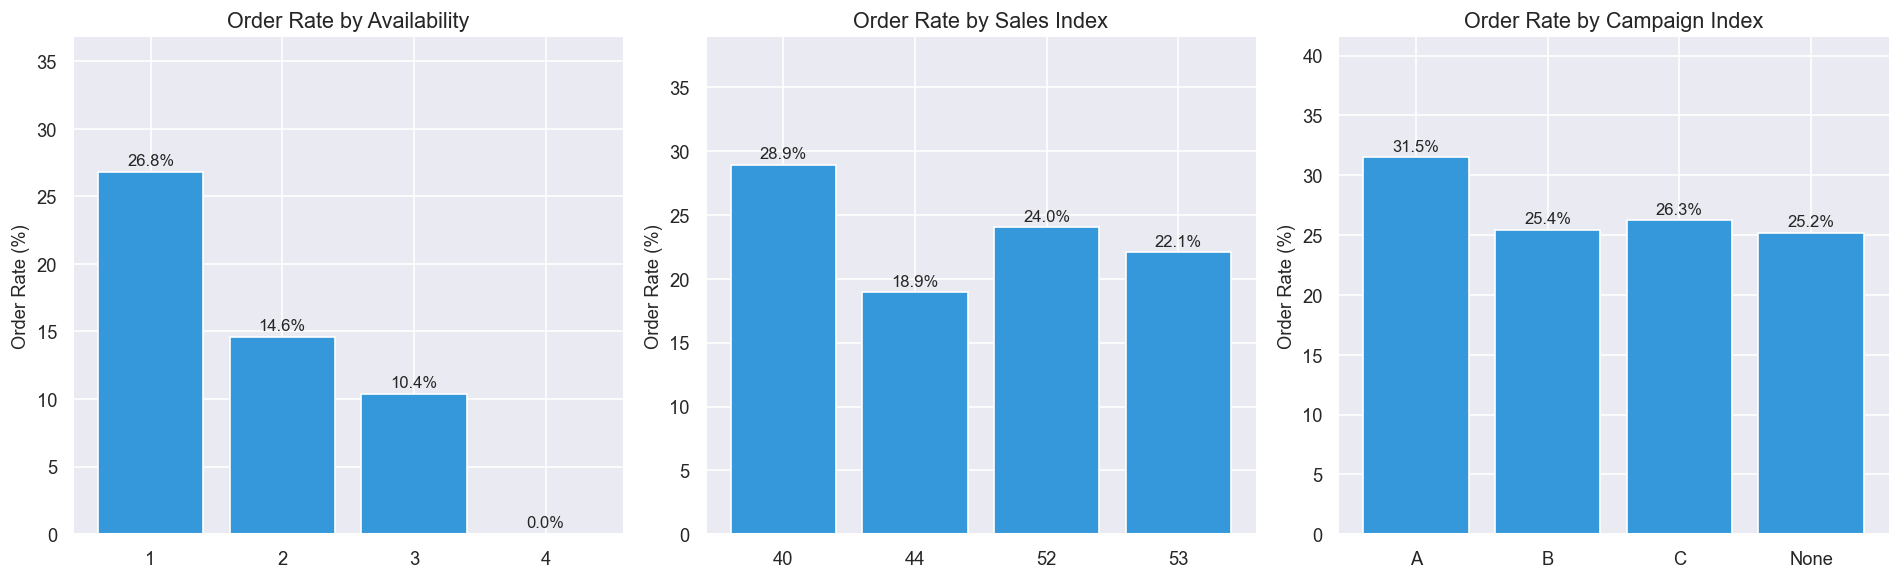

In [37]:
# 5.3 Order rates by categorical features visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_configs = [
    ('availability', train, 'Order Rate by Availability'),
    ('salesIndex', train_with_items, 'Order Rate by Sales Index'),
    ('campaignIndex', train_with_items, 'Order Rate by Campaign Index'),
]

for ax, (col, source, title) in zip(axes, cat_configs):
    if col == 'campaignIndex':
        filled = source[col].fillna('None')
        rates = filled.groupby(filled).apply(
            lambda x: source.loc[x.index, 'order'].mean() * 100
        ).round(2)
    else:
        rates = source.groupby(col)['order'].mean().mul(100).round(2)

    bars = ax.bar(rates.index.astype(str), rates.values, color='#3498db', edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Order Rate (%)', fontsize=11)
    ax.set_ylim(0, rates.max() + 10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '05_categorical_order_rates.png', bbox_inches='tight')
plt.show()

> **Categorical features insight:** All three categorical features show meaningful variation in order rates. Availability is the strongest signal, with a clear monotonic decline from 26.8% at status 1 down to essentially 0% at status 4, confirming that product availability is a critical driver of purchase completion. Sales index shows moderate variation (18.9% to 28.9% across codes 40, 44, 52, 53), with code 40 converting at the highest rate. Campaign index reveals that campaign A stands out with a 31.5% order rate, while campaigns B and C (25.4% and 26.3%) perform only marginally above the no-campaign baseline of 25.2%, suggesting campaign A targets higher-intent customers or higher-demand products. All three features will be treated as categorical in Phase 3 and will be retained as model features.

### 5.4 Quantity Estimation

The dataset does not include an explicit quantity field. We estimate it as `revenue / price`
for rows where a purchase occurred (`order == 1`). This section examines the distribution
of estimated quantities, the proportion of single-unit purchases, and the outlier threshold
that will inform capping decisions in Phase 3.

In [38]:
# 5.4 Estimate quantity and compute descriptive statistics
orders = train[train['order'] == 1].copy()
orders['estimated_quantity'] = orders['revenue'] / orders['price']
qty = orders['estimated_quantity'].dropna()

# IQR approach commented out: Q1 = Q3 = 1.0 maybe because high % of purchases are single-unit.
# This makes IQR = 0, so the 1.5*IQR rule flags every order above 1 unit (20% of all
# orders) as an outlier, which is statistically meaningless for this distribution.

# Q1, Q3 = qty.quantile([0.25, 0.75])
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# outliers = ((qty < lower_bound) | (qty > upper_bound))

# Use 99th percentile instead: gives a meaningful cap for Phase 3 feature engineering.
upper_bound = qty.quantile(0.99)
outliers = qty > upper_bound

print(qty.describe().round(2))
print(f"\nProportion of single-unit purchases     : {(qty == 1).mean():.1%}")
print(f"99th percentile threshold               : {upper_bound:.2f}")
print(f"Outliers above threshold                : {outliers.sum():,} ({outliers.mean() * 100:.2f}%)")

count   705090.00
mean         1.38
std          1.58
min          1.00
25%          1.00
50%          1.00
75%          1.00
max        306.00
Name: estimated_quantity, dtype: float64

Proportion of single-unit purchases     : 79.7%
99th percentile threshold               : 5.00
Outliers above threshold                : 6,897 (0.98%)


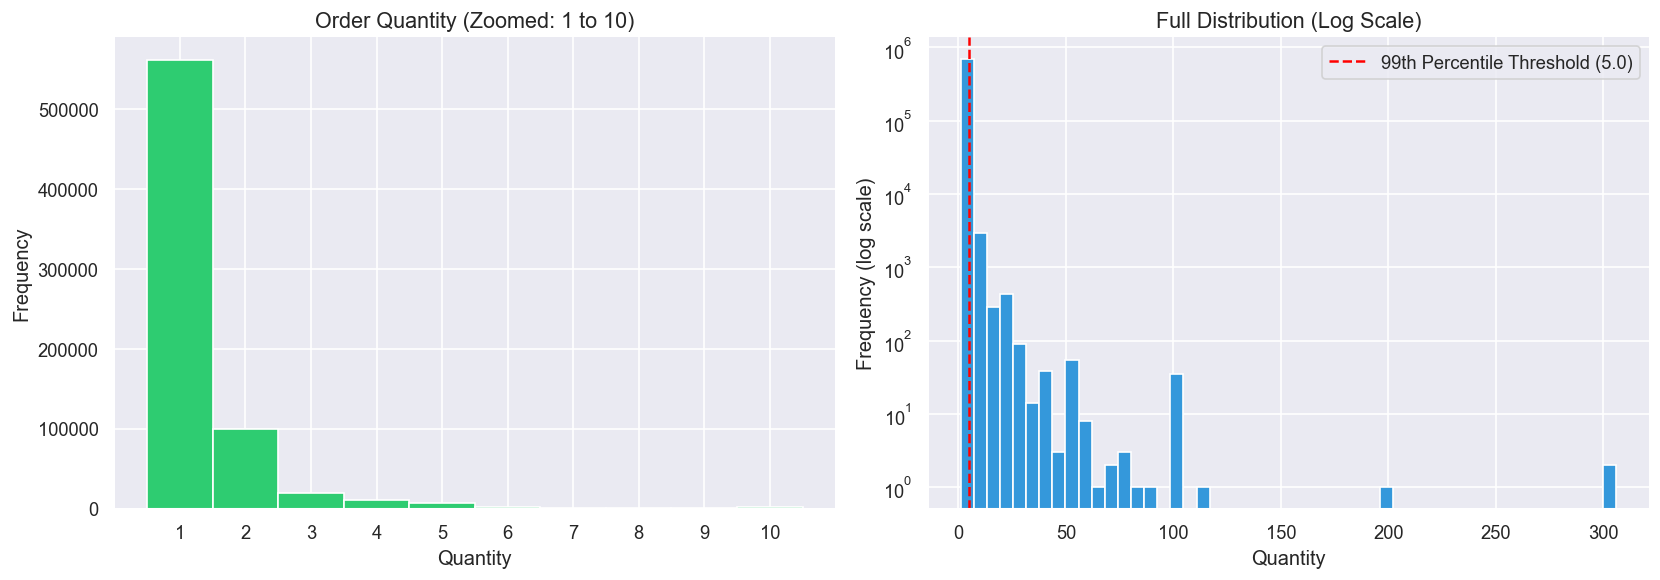

In [39]:
# 5.4 Quantity distribution: zoomed view and full log-scale view
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(qty[qty <= 10], bins=range(1, 12), edgecolor='white', color='#2ecc71', align='left')
axes[0].set_title('Order Quantity (Zoomed: 1 to 10)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 11))
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(qty, bins=50, edgecolor='white', color='#3498db')
axes[1].set_yscale('log')
axes[1].axvline(upper_bound, linestyle='--', color='red',
                label=f'99th Percentile Threshold ({upper_bound:.1f})')
axes[1].set_title('Full Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '06_quantity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Quantity insight:** Nearly 80% of orders are single-unit purchases, and the median is 1.0.
> The distribution drops sharply after quantity 2 and has a very long tail extending to 306,
> likely representing bulk or institutional purchases. The standard IQR outlier method fails
> here because Q1 = Q3 = 1.0, making the spread zero and incorrectly flagging every multi-unit
> order as an outlier. The 99th percentile (5 units) is a more appropriate threshold: it sits
> naturally at the point where the tail begins, capturing only the 0.98% of orders that are
> genuinely extreme. In Phase 3, quantities above 5 will be capped before any quantity
> prediction task. So, the model doesn't try to learn from that extreme values and distorts its predictions

### 5.5 High-Cardinality Features

`manufacturer`, `group`, and `category` each have hundreds of distinct values. Before using
them as model features we need to answer two questions: do different values convert at
meaningfully different rates (is there signal worth keeping?), and how many values are so
rare that their order rate estimate is unreliable (is there noise worth removing?). This
section examines the top 10 most frequent values for each feature to answer both questions.

In [40]:
# 5.5 High-cardinality features: coverage and order rates for top values
train_with_items_full = train.merge(
    items[['pid', 'manufacturer', 'group', 'category']], on='pid', how='left'
)

high_card_cols = ['manufacturer', 'group', 'category']

for col in high_card_cols:
    n_unique = train_with_items_full[col].nunique()
    top10 = (
        train_with_items_full.groupby(col)['order']
        .agg(interactions='count', order_rate='mean')
        .sort_values('interactions', ascending=False)
        .head(10)
    )
    top10['order_rate'] = (top10['order_rate'] * 100).round(2)
    top10_coverage = top10['interactions'].sum() / len(train_with_items_full) * 100

    print(f"{col}: {n_unique} unique values")
    print(f"Top 10 cover {top10_coverage:.1f}% of all interactions")
    print(top10.to_string())
    print()

manufacturer: 1065 unique values
Top 10 cover 31.1% of all interactions
              interactions  order_rate
manufacturer                          
84                  146079       35.47
82                  111712       33.88
18                  105665       30.14
52                  104694       34.56
156                  89827       10.61
176                  77729       34.55
105                  62011       35.29
4                    55928       36.32
37                   51836       32.62
1                    51017       26.91

group: 533 unique values
Top 10 cover 29.8% of all interactions
          interactions  order_rate
group                             
22OI3           159787       23.63
2FOI            148449       22.80
21OKG           110419       14.29
18OI0EOI         96243       37.88
21OK3            71052       20.95
1COS2            55938        2.25
1DOIF0ZO         47419       24.82
18OZ00IS         46010       33.50
1COI00OT         44421       54.78
20OHG     

> **High-cardinality features insight:** All three features have a large number of unique
> values (1,065 manufacturers, 533 groups, 409 categories), and the top 10 most frequent
> values cover only 22 to 31% of all interactions, confirming a long tail of rarely seen
> values. The features are worth keeping: order rates vary dramatically across the top
> values, from 2.25% to 54.78% for group and 5.39% to 46.79% for category, meaning which
> manufacturer, group, or category a product belongs to genuinely influences whether it gets
> ordered. The risk is in the tail: values that appear in only a handful of interactions will
> have unreliable order rate estimates and will add noise rather than signal. In Phase 3,
> values below a minimum frequency threshold will be grouped into a single "other" category
> to keep the signal from common values while discarding the noise from rare ones.

### 5.6 Temporal Patterns

We examine how interaction volume and order rate evolve across the 92-day observation period.
The goal is to identify any structural shifts in user behavior over time that should be
captured as a feature in Phase 3.

In [41]:
# 5.6 Daily interaction volume and order rate over time
daily = train.groupby('day').agg(
    interactions=('lineID', 'count'),
    orders=('order', 'sum'),
).reset_index()
daily['order_rate'] = daily['orders'] / daily['interactions'] * 100

# Explore the data before drawing conclusions
print("Daily interaction volume summary:")
print(daily['interactions'].describe().round(0))
print(f"\nDay with highest volume : day {daily.loc[daily['interactions'].idxmax(), 'day']}")
print(f"Day with lowest volume  : day {daily.loc[daily['interactions'].idxmin(), 'day']}")
print(f"\nDay with highest order rate : day {daily.loc[daily['order_rate'].idxmax(), 'day']}")
print(f"Day with lowest order rate  : day {daily.loc[daily['order_rate'].idxmin(), 'day']}")
print(f"\nFirst 10 days avg interactions : {daily.loc[daily['day'] <= 10, 'interactions'].mean():,.0f}")
print(f"Last 10 days avg interactions  : {daily.loc[daily['day'] >= 83, 'interactions'].mean():,.0f}")

Daily interaction volume summary:
count      92.00
mean    29957.00
std      7438.00
min     13548.00
25%     24792.00
50%     31157.00
75%     36207.00
max     41638.00
Name: interactions, dtype: float64

Day with highest volume : day 33
Day with lowest volume  : day 16

Day with highest order rate : day 3
Day with lowest order rate  : day 44

First 10 days avg interactions : 21,250
Last 10 days avg interactions  : 32,220


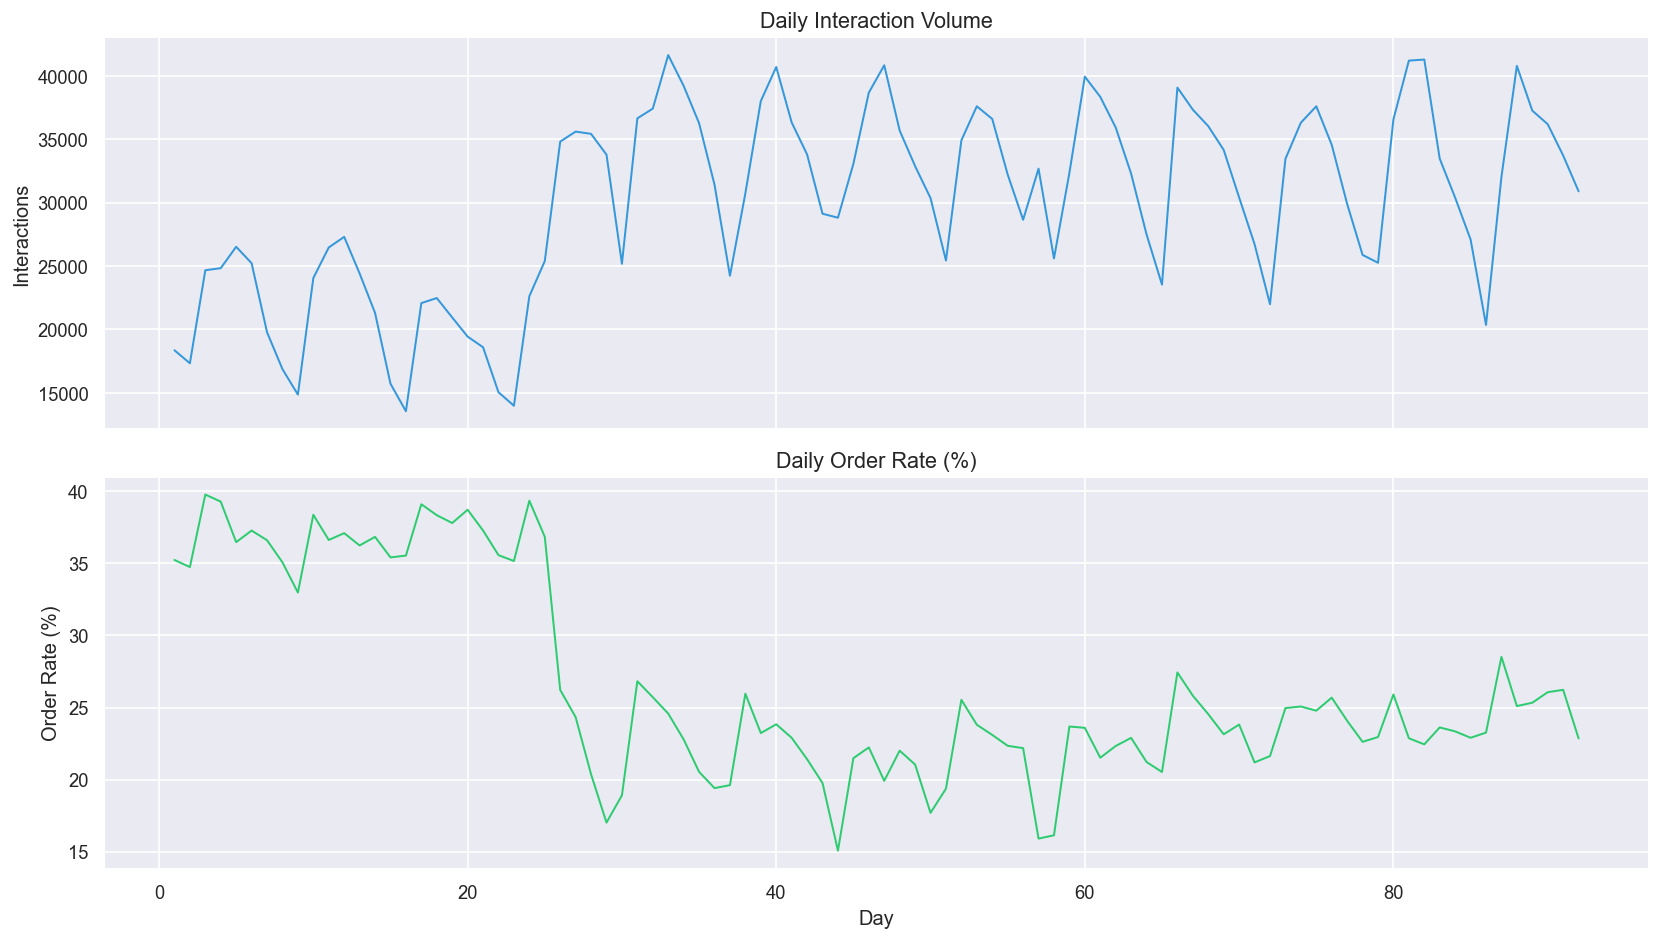

In [42]:
# 5.6 Visualize daily volume and order rate to identify any structural shifts
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily['day'], daily['interactions'], color='#3498db', linewidth=1.2)
axes[0].set_title('Daily Interaction Volume', fontsize=13)
axes[0].set_ylabel('Interactions')


axes[1].plot(daily['day'], daily['order_rate'], color='#2ecc71', linewidth=1.2)
axes[1].set_title('Daily Order Rate (%)', fontsize=13)
axes[1].set_ylabel('Order Rate (%)')
axes[1].set_xlabel('Day')


plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '07_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

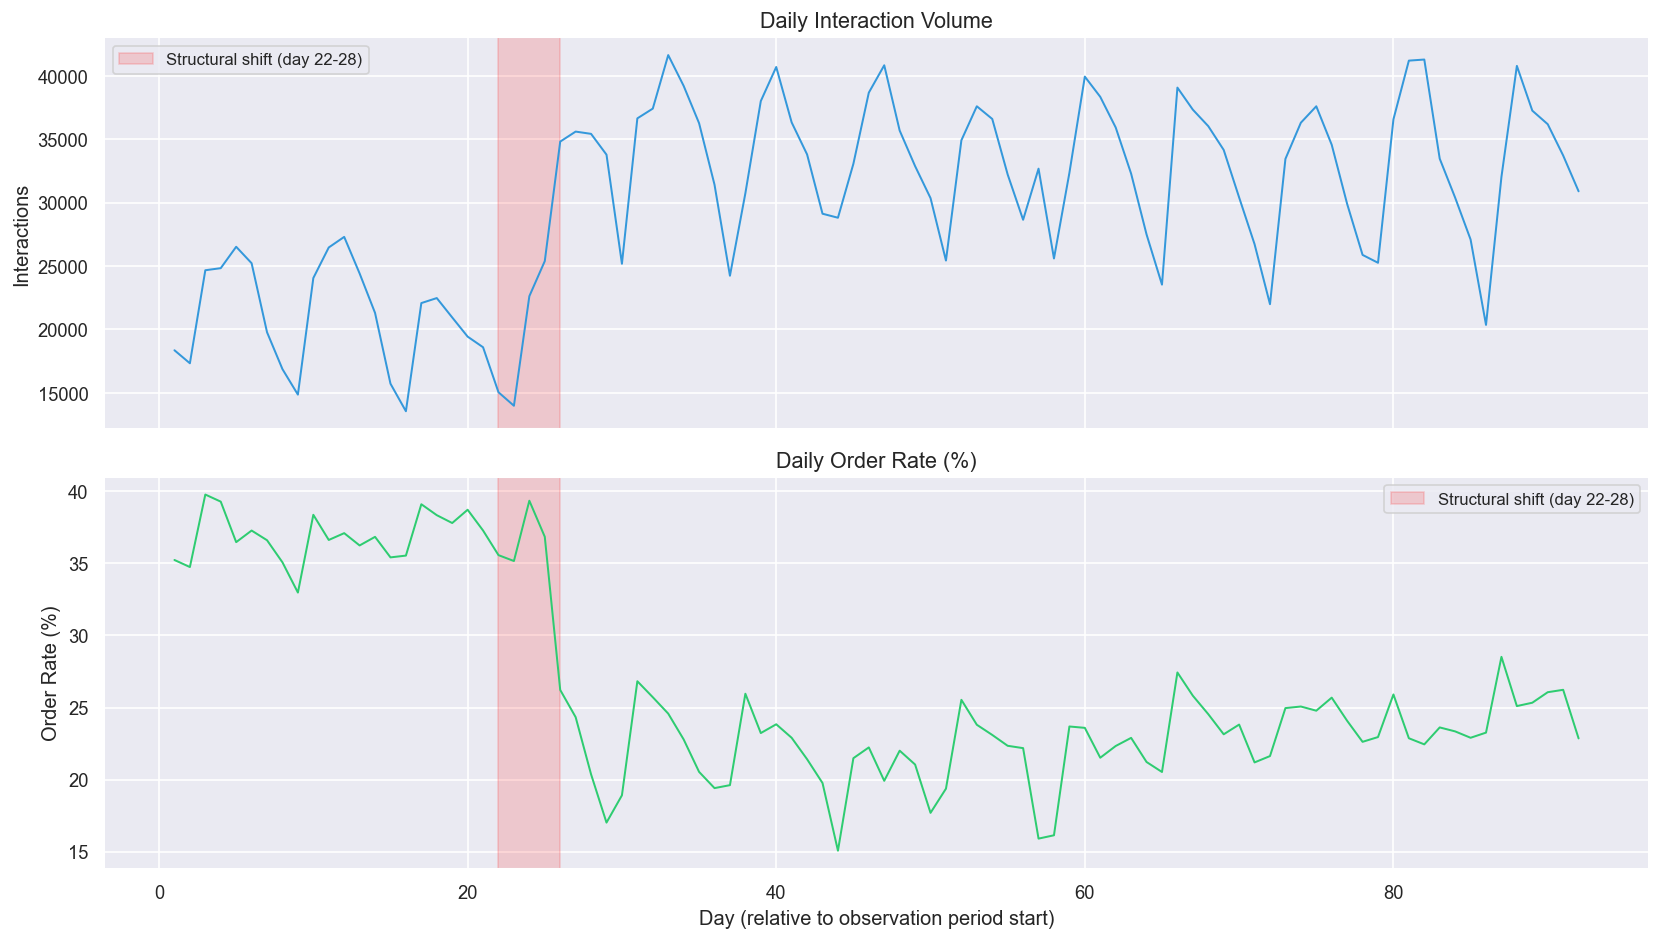

Largest single-day order rate drop detected at: day 26

Before day 26:
  Avg daily interactions : 20,873
  Avg order rate         : 36.88%

After day 26:
  Avg daily interactions : 33,346
  Avg order rate         : 22.73%

Volume change     : 59.8%
Order rate change : -14.15 percentage points


In [43]:
# 5.6 Annotate the structural shift identified from the chart
SHIFT_DAY = 28

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily['day'], daily['interactions'], color='#3498db', linewidth=1.2)
axes[0].axvspan(22, 26, alpha=0.15, color='red', label='Structural shift (day 22-28)')
axes[0].set_title('Daily Interaction Volume', fontsize=13)
axes[0].set_ylabel('Interactions')
axes[0].legend(fontsize=10)


axes[1].plot(daily['day'], daily['order_rate'], color='#2ecc71', linewidth=1.2)
axes[1].axvspan(22, 26, alpha=0.15, color='red', label='Structural shift (day 22-28)')
axes[1].set_title('Daily Order Rate (%)', fontsize=13)
axes[1].set_ylabel('Order Rate (%)')
axes[1].set_xlabel('Day (relative to observation period start)')
axes[1].legend(fontsize=10)


plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '07b_temporal_shift.png', dpi=150, bbox_inches='tight')
plt.show()


# 5.6 Quantify the behavioral shift: detect breakpoint from data
# Find the day with the largest single-day drop in order rate
daily['order_rate_change'] = daily['order_rate'].diff()
SHIFT_DAY = daily.loc[daily['order_rate_change'].idxmin(), 'day']

print(f"Largest single-day order rate drop detected at: day {SHIFT_DAY}")

before = daily[daily['day'] < SHIFT_DAY]
after  = daily[daily['day'] >= SHIFT_DAY]

print(f"\nBefore day {SHIFT_DAY}:")
print(f"  Avg daily interactions : {before['interactions'].mean():,.0f}")
print(f"  Avg order rate         : {before['order_rate'].mean():.2f}%")
print(f"\nAfter day {SHIFT_DAY}:")
print(f"  Avg daily interactions : {after['interactions'].mean():,.0f}")
print(f"  Avg order rate         : {after['order_rate'].mean():.2f}%")

volume_change = (after['interactions'].mean() / before['interactions'].mean() - 1) * 100
rate_change   = after['order_rate'].mean() - before['order_rate'].mean()

print(f"\nVolume change     : {volume_change:.1f}%")
print(f"Order rate change : {rate_change:.2f} percentage points")

> **Temporal insight:** The observation period spans 92 days and shows a clear structural
> break at day 26. Before day 26, daily interactions averaged 20,873 with an order rate of
> 36.88%. From day 26 onward, daily interactions jumped by 59.8% to an average of 33,346
> while the order rate dropped by 14.15 percentage points to 22.73%, a level it never
> recovered from. More traffic came in but a much smaller proportion converted. This pattern
> is consistent with a promotional or marketing event that attracted a large wave of
> low-intent browsers. The regular fluctuation visible throughout both charts suggests a
> weekly cycle, though the actual calendar dates are unknown since the `day` column is a
> relative counter from day 1 to day 92, not a real-world date. In Phase 3, a binary
> feature `is_post_shift` (0 before day 26, 1 from day 26 onward) will be added to let
> the model distinguish between the two behavioral regimes.

### 5.7 Content Column Inspection

The `content` column in items represents the package size of each product. It is stored as
a string and is expected to contain mixed formats: plain numbers like `"10.0"` and
multiplier patterns like `"5X10"` meaning 5 packs of 10 units. Before this column can be
used as a feature, we need to understand how many rows follow each format and whether
a numeric value can be reliably extracted from both.

In [44]:
# 5.7 Inspect content column formats
import re

def classify_content(value: str) -> str:
    """Classify a content value as numeric, multiplier, or unknown format."""
    if pd.isna(value):
        return 'missing'
    value = str(value).strip()
    if re.match(r'^\d+(\.\d+)?$', value):
        return 'numeric'
    if re.match(r'^\d+(\.\d+)?([Xx]\d+(\.\d+)?)+$', value):
        return 'multiplier'
    return 'unknown'

items['content_format'] = items['content'].apply(classify_content)

format_counts = items['content_format'].value_counts()
format_pct    = (format_counts / len(items) * 100).round(2)

print("Content column format breakdown:")
for fmt, count, pct in zip(format_counts.index, format_counts.values, format_pct.values):
    print(f"  {fmt:<15} {count:>6,} ({pct:.2f}%)")

print(f"\nSample numeric values    : {items.loc[items['content_format'] == 'numeric', 'content'].head(10).tolist()}")
print(f"Sample multiplier values : {items.loc[items['content_format'] == 'multiplier', 'content'].head(10).tolist()}")
print(f"Sample unknown values    : {items.loc[items['content_format'] == 'unknown', 'content'].head(10).tolist()}")


Content column format breakdown:
  numeric         20,741 (94.13%)
  multiplier       1,292 (5.86%)
  unknown              2 (0.01%)

Sample numeric values    : ['80', '80', '10', '80', '8', '10', '15', '80', '10', '30']
Sample multiplier values : ['5X10', '14X20', '4X200', '30X0.6', '60X0.6', '120X0.6', '5X5', '4X200', '4X200', '6X5']
Sample unknown values    : ['PAK', 'L   125']


> **Content column insight:** The `content` column follows two clear formats. The vast
> majority of values (94.13%) are plain numeric, representing a single package quantity
> such as 80 or 30. The remaining 5.86% follow a multiplier format (e.g., `5X10`, `30X0.6`) and double multipliers too
> representing a count times a unit size, maybe. Only 2 values (0.01%) are unclassifiable and
> will be treated as missing. In Phase 3, numeric values will be parsed directly as floats,
> and multiplier values will be converted to a total quantity by multiplying the two or three
> components (e.g., `5X10` becomes 50). This gives a single numeric `content_parsed`
> feature that captures package size in a consistent unit across all products.

## 6. Bivariate Analysis

### 6.1 Price Competitiveness by Action Class

We examine whether users who order, basket, or click differ in how competitively priced
the product was at the time of their interaction. We use the log of the price-to-competitor
ratio so that "10% cheaper" and "10% more expensive" are symmetric around zero.
A value below zero means the pharmacy is cheaper than the competitor; above zero means
the pharmacy is more expensive.

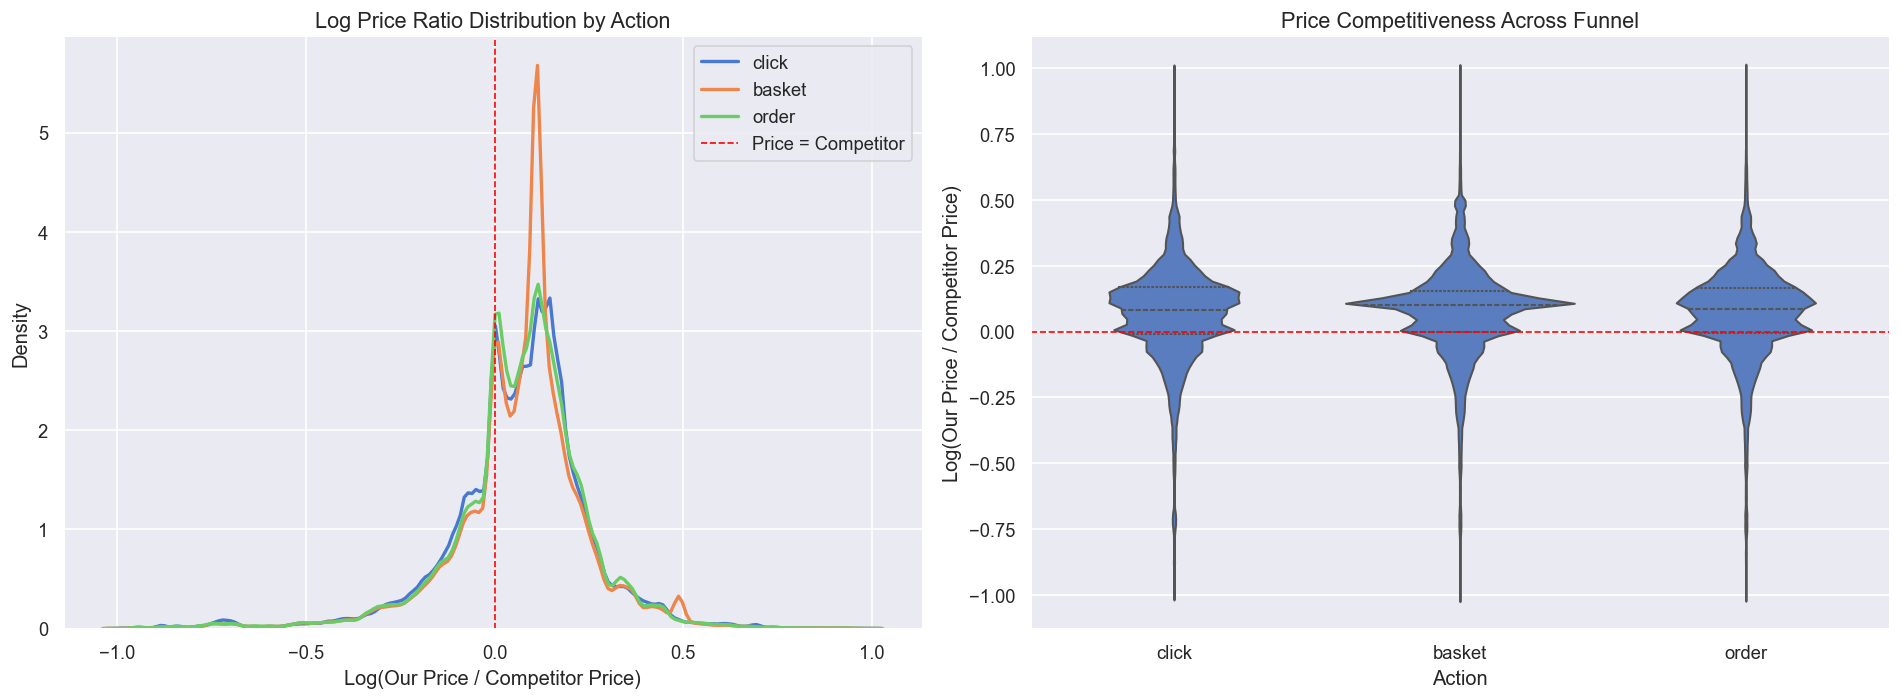


CLICK
  Median log ratio          : 0.0835
  Mean log ratio            : 0.0662
  % cheaper than competitor : 28.45%

BASKET
  Median log ratio          : 0.1003
  Mean log ratio            : 0.0724
  % cheaper than competitor : 25.31%

ORDER
  Median log ratio          : 0.0841
  Mean log ratio            : 0.0693
  % cheaper than competitor : 26.46%


In [45]:
# 6.1 Log price ratio distribution by action class
viz_data = train.dropna(subset=['competitorPrice']).copy()
viz_data = viz_data[viz_data['competitorPrice'] > 0]
viz_data['log_price_ratio'] = np.log(viz_data['price'] / viz_data['competitorPrice'])
viz_data = viz_data[
    (viz_data['log_price_ratio'] > -1) & (viz_data['log_price_ratio'] < 1)
]

# Create action column for grouping
viz_data['action'] = np.select(
    [viz_data['click'] == 1, viz_data['basket'] == 1, viz_data['order'] == 1],
    ['click', 'basket', 'order'],
    default= 'unknown'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for action in ['click', 'basket', 'order']:
    subset = viz_data.loc[viz_data['action'] == action, 'log_price_ratio']
    sns.kdeplot(subset, ax=axes[0], linewidth=2, label=action)
axes[0].axvline(0, linestyle='--', color='red', linewidth=1, label='Price = Competitor')
axes[0].set_title('Log Price Ratio Distribution by Action', fontsize=13)
axes[0].set_xlabel('Log(Our Price / Competitor Price)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

sns.violinplot(data=viz_data, x='action', y='log_price_ratio',
               order=['click', 'basket', 'order'],
               inner='quartile', ax=axes[1])
axes[1].axhline(0, linestyle='--', color='red', linewidth=1)
axes[1].set_title('Price Competitiveness Across Funnel', fontsize=13)
axes[1].set_ylabel('Log(Our Price / Competitor Price)')
axes[1].set_xlabel('Action')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '08_price_ratio_by_action.png', dpi=150, bbox_inches='tight')
plt.show()

for action in ['click', 'basket', 'order']:
    subset = viz_data.loc[viz_data['action'] == action, 'log_price_ratio']
    print(f"\n{action.upper()}")
    print(f"  Median log ratio          : {np.median(subset):.4f}")
    print(f"  Mean log ratio            : {subset.mean():.4f}")
    print(f"  % cheaper than competitor : {(subset < 0).mean() * 100:.2f}%")

> **Price competitiveness insight:** All three action classes show nearly identical log price
> ratio distributions, with medians clustered tightly between 0.08 and 0.10 and roughly
> 25 to 28% of interactions occurring when the pharmacy is cheaper than the competitor.
> If price competitiveness was driving purchase decisions we would expect the order group to
> have a clearly lower ratio (pharmacy cheaper) compared to the click group. But the three curves
> sit almost on top of each other. This means that how competitively priced a product is relative to the competitor
> has very little influence on whether a user clicks, adds to basket, or orders. The
> pharmacy is consistently priced slightly above competitors across all three action types,
> yet orders still happen at a 26% rate. This suggests that customers are not purely
> price-comparing against competitors when making purchase decisions, and that other
> factors such as availability, advertising, and product type are stronger drivers of
> conversion. The `log_price_ratio` feature may still be worth including in the model
> but should not be expected to be a top predictor.

### 6.2 Price Elasticity

We examine how order rate changes as price increases. If demand is elastic, order rate
should decline as price rises. We split all interactions into 10 equal-sized price deciles
and measure the order rate in each, then fit a logistic regression to quantify the
relationship and estimate an elasticity coefficient.

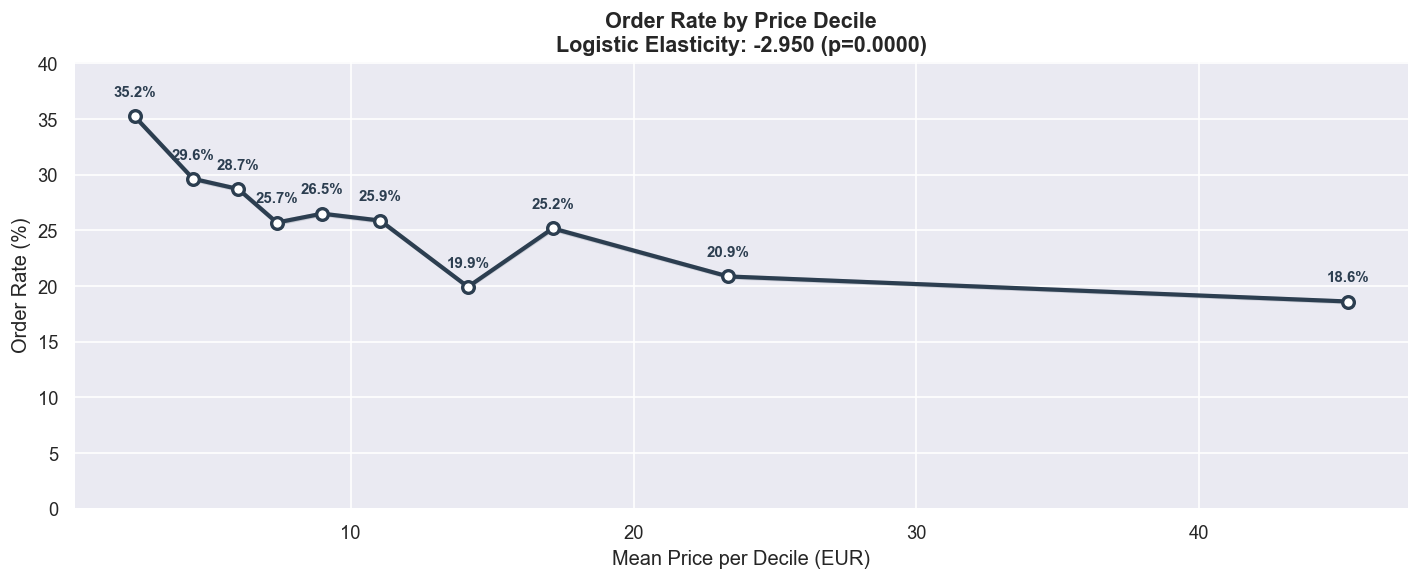

Price Decile Summary:
   price_decile  mean_price  order_rate_percent  confidence_interval_lower  confidence_interval_upper  count
  (0.019, 3.58]        2.36               35.24                      35.07                      35.42 280481
   (3.58, 5.23]        4.43               29.63                      29.46                      29.80 275041
   (5.23, 6.55]        6.03               28.71                      28.55                      28.87 315868
   (6.55, 7.98]        7.39               25.70                      25.52                      25.88 231166
   (7.98, 9.85]        8.99               26.50                      26.34                      26.66 297596
  (9.85, 12.04]       11.04               25.88                      25.71                      26.05 258087
 (12.04, 15.35]       14.15               19.92                      19.79                      20.06 335501
 (15.35, 18.64]       17.14               25.18                      24.99                      25.36 2153

In [46]:
# 6.2 Price elasticity: order rate by price decile with logistic regression

# Keep only rows with a valid price and drop NaNs
data = train[['price', 'order']].dropna().copy()
data = data[data['price'] > 0]

# Split price range into 10 equal-sized groups where each group
# contains roughly the same number of interactions (quantile cut)
# duplicates='drop' handles edge cases where price values repeat at boundaries
NUMBER_OF_DECILES = 10
data['price_decile'] = pd.qcut(data['price'], q=NUMBER_OF_DECILES, duplicates='drop')

# For each decile: average order rate, row count, and mean price
# mean_price gives us a single x-axis value to plot per decile
elasticity = data.groupby('price_decile', observed=True).agg(
    order_rate=('order', 'mean'),
    count=('order', 'count'),
    mean_price=('price', 'mean')
).reset_index()
elasticity['order_rate_percent'] = elasticity['order_rate'] * 100

# 95% confidence intervals using the binomial standard error formula
# sqrt(p * (1-p) / n) gives the uncertainty around each decile's order rate
# Wider intervals mean fewer observations and a less reliable estimate
Z_SCORE_95_PERCENT = 1.96 # go 1.96 standard errors above and below my estimate
elasticity['standard_error'] = np.sqrt(
    elasticity['order_rate'] * (1 - elasticity['order_rate']) / elasticity['count']
)
elasticity['confidence_interval_upper'] = (
    (elasticity['order_rate'] + Z_SCORE_95_PERCENT * elasticity['standard_error']) * 100
)
elasticity['confidence_interval_lower'] = (
    (elasticity['order_rate'] - Z_SCORE_95_PERCENT * elasticity['standard_error']) * 100
)

# Logistic regression on log(price) vs order flag
# We use log(price) because price has a right-skewed distribution
# The coefficient tells us: for a 1% increase in price, how much does
# the log-odds of ordering change?
feature_matrix    = sm.add_constant(np.log(data['price']))
logistic_model    = sm.Logit(data['order'], feature_matrix).fit(disp=False)
price_coefficient = logistic_model.params.iloc[1]
p_value           = logistic_model.pvalues.iloc[1]
mean_order_probability = data['order'].mean()

# Convert log-odds coefficient to a probability-scale elasticity estimate
# This gives: for a 1-unit increase in price, how much does order probability change?
elasticity_estimate = price_coefficient * data['price'].mean() * (1 - mean_order_probability)

# Percentage drop from the cheapest decile to most expensive decile
conversion_drop_percent = (
    (elasticity['order_rate_percent'].iloc[0] - elasticity['order_rate_percent'].iloc[-1])
    / elasticity['order_rate_percent'].iloc[0] * 100
)

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
x_values = elasticity['mean_price']
y_values = elasticity['order_rate_percent']

# Shaded band shows the 95% confidence interval around each decile's order rate
ax.fill_between(
    x_values,
    elasticity['confidence_interval_lower'],
    elasticity['confidence_interval_upper'],
    alpha=0.15, color='#2c3e50'
)

# Line with circle markers: one point per decile
ax.plot(x_values, y_values, 'o-', color='#2c3e50', linewidth=2.5, markersize=7,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2c3e50')

# Annotate each point with its exact order rate percentage
for x_point, y_point in zip(x_values, y_values):
    ax.annotate(f'{y_point:.1f}%', (x_point, y_point), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9,
                fontweight='bold', color='#2c3e50')

ax.set_xlabel('Mean Price per Decile (EUR)', fontsize=12)
ax.set_ylabel('Order Rate (%)', fontsize=12)

# Title uses computed values so it reflects whatever the data actually shows
ax.set_title(
    f'Order Rate by Price Decile\n'
    f'Logistic Elasticity: {elasticity_estimate:.3f} (p={p_value:.4f})',
    fontsize=13, fontweight='bold'
)
ax.set_ylim(0, y_values.max() + 5)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / '09_price_elasticity.png', dpi=150, bbox_inches='tight')
plt.show()

print("Price Decile Summary:")
print(elasticity[['price_decile', 'mean_price', 'order_rate_percent',
                  'confidence_interval_lower', 'confidence_interval_upper', 'count']]
      .to_string(index=False))
print(f"\nElasticity Estimate : {elasticity_estimate:.3f} (p={p_value:.6f})")
print(f"Conversion Drop     : {conversion_drop_percent:.1f}% from cheapest to most expensive decile")

> **Price elasticity insight:** Order rate declines as price increases, dropping from 35.2%
> in the cheapest decile (mean price EUR 2.36) to 18.6% in the most expensive decile
> (mean price EUR 45.26). This is a 47.2% reduction in conversion from the cheapest to
> the most expensive products, meaning cheap products convert nearly twice as often as
> expensive ones. The logistic elasticity estimate of -2.950 confirms the direction:
> negative means higher price, lower order probability. The p-value of essentially zero
> means this relationship is real and not random chance.
>
> However, the decline is not perfectly smooth. The dip to 19.9% in the EUR 12 to 15
> range followed by a recovery to 25.2% suggests that price alone does not fully explain
> order rate, and that product mix within each decile (category, availability, advertising)
> also plays a role. The confidence intervals are very narrow across all deciles due to the
> large sample size, confirming that these estimates are reliable.
>
> In Phase 3, price will be included as a feature in its raw form and as ratio features.
> Additionally, the relationship between price and order rate is not a straight line: it
> drops steeply at low prices and flattens at high prices. Most models assume a linear
> relationship by default. Log-transforming price compresses the large price range and
> makes the curve closer to a straight line, which means the model can learn the
> relationship more accurately without needing to discover the non-linearity on its own.

## 7. Leakage Audit

Before moving to Phase 3, columns that must never be used as
model features to avoid data leakage at prediction time, causing the model to appear accurate during
training but fail in production.

| Column    | Reason                                                | Action             |
|-----------|-------------------------------------------------------|--------------------|
| `revenue` | Only nonzero for orders. Directly encodes the target. | Exclude entirely   |
| `click`   | One of the three target classes. Leaks the answer.    | Use as target only |
| `basket`  | One of the three target classes. Leaks the answer.    | Use as target only |
| `order`   | One of the three target classes. Leaks the answer.    | Use as target only |
| `lineID`  | Unique row identifier with no predictive signal.      | Exclude entirely   |

All remaining columns are candidates for feature engineering in Phase 3.

## 8. Phase 2 Summary

### 8.1 Key Findings

| #  | Feature                               | Finding                                                                                           | Modeling Implication                                                     |
|----|---------------------------------------|---------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------|
| 1  | Target                                | 57.43% click, 16.98% basket, 25.58% order. Moderate imbalance.                                    | Stratified split. Class weights if needed.                               |
| 2  | Purchase funnel                       | 42.57% showed intent. Of those, 60.10% converted.                                                 | Primary lever is moving browsers to intent stage.                        |
| 3  | Quantity                              | 79.7% single-unit. Long tail up to 306. 99th percentile at 5 units.                               | Cap at 5 units in Phase 3.                                               |
| 4  | price, competitorPrice, rrp           | All three right-skewed. Correlated above 0.94.                                                    | Replace with ratio features. Do not use raw columns together.            |
| 5  | competitorPrice                       | 3.65% missing. 976 zeros are not real prices.                                                     | Recode zeros to NaN. Add binary missingness flag.                        |
| 6  | adFlag                                | Advertised: 32.2% order rate. Not advertised: 22.5%.                                              | Strong predictor. Retain as feature.                                     |
| 7  | genericProduct                        | Generic: 37.6% order rate. Branded: 24.2%.                                                        | Strong predictor. Retain as feature.                                     |
| 8  | availability                          | Monotonic decline from 26.8% at status 1 to ~0% at status 4.                                      | Strongest categorical predictor. Treat as categorical.                   |
| 9  | salesIndex                            | Order rates vary from 18.9% to 28.9% across four codes.                                           | Moderate signal. Treat as categorical.                                   |
| 10 | campaignIndex                         | Campaign A: 31.5%. B: 25.4%. C: 26.3%. No campaign: 25.2%.                                        | Recode NaN to "none". Treat as categorical.                              |
| 11 | manufacturer, group, category         | Order rates vary widely (2.25% to 54.78%). Long tail of rare values.                              | Retain top values. Group rare values into "other".                       |
| 12 | day                                   | Structural break at day 26. Volume up 59.8%, order rate down 14.15 percentage points permanently. | Add binary feature: is_post_shift (0 before day 26, 1 from day 26).      |
| 13 | content                               | 94.13% numeric. 5.86% multiplier format. 2 unparseable values.                                    | Parse to single numeric feature. Recode 2 unknowns to NaN.               |
| 14 | Log price ratio                       | Nearly identical distribution across click, basket, order.                                        | Weak predictor relative to raw price. Include but expect low importance. |
| 15 | Price elasticity                      | Order rate drops from 35.2% to 18.6% across deciles. Elasticity -2.950 (p < 0.0001).              | Include log(price) as feature. Non-linear relationship confirmed.        |
| 16 | revenue, click, basket, order, lineID | Leakage risk or no predictive signal.                                                             | Exclude from feature matrix entirely.                                    |

---

### 8.2 Feature Retention Decisions

| Feature           | Decision             | Phase 3 Action                                                  |
|-------------------|----------------------|-----------------------------------------------------------------|
| `price`           | Retain               | Include as log(price) and in ratio features                     |
| `competitorPrice` | Retain with cleaning | Recode zeros to NaN. Add `competitor_price_missing` binary flag |
| `rrp`             | Retain via ratio     | Use in price/rrp ratio only. Drop raw column                    |
| `adFlag`          | Retain               | Use as binary feature                                           |
| `availability`    | Retain               | Encode as categorical                                           |
| `genericProduct`  | Retain               | Use as binary feature                                           |
| `salesIndex`      | Retain               | Encode as categorical                                           |
| `campaignIndex`   | Retain               | Recode NaN to "none". Encode as categorical                     |
| `manufacturer`    | Retain with grouping | Group values below frequency threshold into "other"             |
| `group`           | Retain with grouping | Group values below frequency threshold into "other"             |
| `category`        | Retain with grouping | Group values below frequency threshold into "other"             |
| `day`             | Engineer             | Add `is_post_shift` binary feature (breakpoint at day 26)       |
| `content`         | Engineer             | Parse to `content_parsed` numeric feature                       |
| `pid`             | Join key only        | Use to merge datasets. Drop after merge                         |
| `revenue`         | Exclude              | Leakage                                                         |
| `click`           | Exclude              | Target class                                                    |
| `basket`          | Exclude              | Target class                                                    |
| `order`           | Exclude              | Target class                                                    |
| `lineID`          | Exclude              | Row identifier, no signal                                       |

---